# Comparing the infraslow oscillation of sigma power: YASA vs. Luna

Sleep-spindle (sigma, ~12-15 Hz) power is not steady across NREM -- it waxes and
wanes with an **infraslow rhythm** near 0.02 Hz (a ~50 s period), and spindles
cluster on the peaks of that rhythm (Lecci et al., 2017). This notebook measures
that infraslow oscillation two ways on the **same** recording, channel and stage,
and compares the two spindle detectors:

* **Continuous EEG (reference)** -- sigma-band Hilbert power envelope, then its
  low-frequency spectrum (`infraslow.processing.infraslow.sigma_infraslow_oscillation`).
* **Per detector** -- turn each detector's spindle times into a smooth
  spindle-rate series and take *its* infraslow spectrum
  (`spindle_infraslow_oscillation`). YASA vs. Luna is the comparison of interest.

We then plot the **power-frequency** of (a) the infraslow oscillation and (b) the
spindle sigma band, for both detectors, and test the results with
`infraslow.stats`.

> **Run this on a compute node**, not the Sherlock login node. Grab a shell with
> `sh_dev` (or `salloc`) first.

## 1. Setup and load the recording

In [1]:
from infraslow import BioserenityPSGLoader
from infraslow.processing.detection import spindles_detect
from infraslow.processing.detection_luna import spindles_detect_luna
from infraslow.processing.infraslow import (
    sigma_infraslow_oscillation,
    spindle_infraslow_oscillation,
    average_spindle_spectrum,
)
from infraslow.viz import plot_infraslow_spectra, plot_spindle_sigma_spectra
from infraslow.stats import compare_spindle_infraslow, associate_spindle_rate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
loader = BioserenityPSGLoader(
    subject_id="318679",
    sf=200,
    requested_channels=["F3", "F4", "C3", "C4", "O1", "O2"],
).load()

CHANNEL = "C3"      # same channel for both detectors and for the continuous envelope
INCLUDE = (2,)      # restrict spindle detection to N2

data = np.asarray(loader.get_channel(CHANNEL), dtype=float)
sf = float(loader.sf)
duration_sec = len(data) / sf
print(f"{CHANNEL}: {len(data)} samples @ {sf:g} Hz = {duration_sec / 60:.1f} min")

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7fbd9568f230> 



  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1

C3: 5502000 samples @ 200 Hz = 458.5 min


## 2. Detect spindles (YASA & Luna)

Identical channel / stage settings as `demo_compared_spindle.ipynb`; we only need
each detector's spindle **peak times** here.

In [3]:
sp_yasa = spindles_detect(loader, ch_names=CHANNEL, include=INCLUDE)
sp_luna = spindles_detect_luna(loader, ch_names=CHANNEL, include=INCLUDE)

yasa_peaks = sp_yasa.summary()["Peak"].to_numpy()
luna_peaks = sp_luna.summary()["Peak"].to_numpy()
print(f"YASA: {len(yasa_peaks)} spindles | Luna: {len(luna_peaks)} spindles")

03-Jul-26 14:40:59 | WARNING | Hypnogram is SHORTER than data by 30.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


YASA: 308 spindles | Luna: 371 spindles


## 3. Infraslow oscillation of sigma power

`sigma_infraslow_oscillation` gives the detector-independent reference (the slow
spectrum of the continuous sigma-power envelope). `spindle_infraslow_oscillation`
builds each detector's smooth spindle-rate series and takes its slow spectrum.
Each returns an `InfraslowSpectrum` carrying the full spectrum plus the infraslow
peak and the fraction of variance in the infraslow band (`rel_band_power`).

In [4]:
# Reference: continuous sigma-band power on C3.
sigma_spec, t_env, sigma_env = sigma_infraslow_oscillation(data, sf, smooth_sec=1.0)

# Detector-derived: infraslow oscillation of each detector's spindle rate.
yasa_spec, _, yasa_rate = spindle_infraslow_oscillation(yasa_peaks, duration_sec=duration_sec)
luna_spec, _, luna_rate = spindle_infraslow_oscillation(luna_peaks, duration_sec=duration_sec)

for name, spec in [("Sigma power", sigma_spec), ("YASA", yasa_spec), ("Luna", luna_spec)]:
    period = 1.0 / spec.peak_freq if spec.peak_freq else float("nan")
    print(f"{name:12s} infraslow peak {spec.peak_freq:.4f} Hz (~{period:4.0f} s), "
          f"rel-band power {spec.rel_band_power:.3f}")

Sigma power  infraslow peak 0.0200 Hz (~  50 s), rel-band power 0.495
YASA         infraslow peak 0.0100 Hz (~ 100 s), rel-band power 0.687
Luna         infraslow peak 0.0100 Hz (~ 100 s), rel-band power 0.671


## 4. Power-frequency of the infraslow oscillation

Low-frequency spectra overlaid (log power). Both detectors' spindle-rate spectra
should peak in the shaded infraslow band, tracking the continuous sigma-power
reference. Markers show each curve's in-band peak.

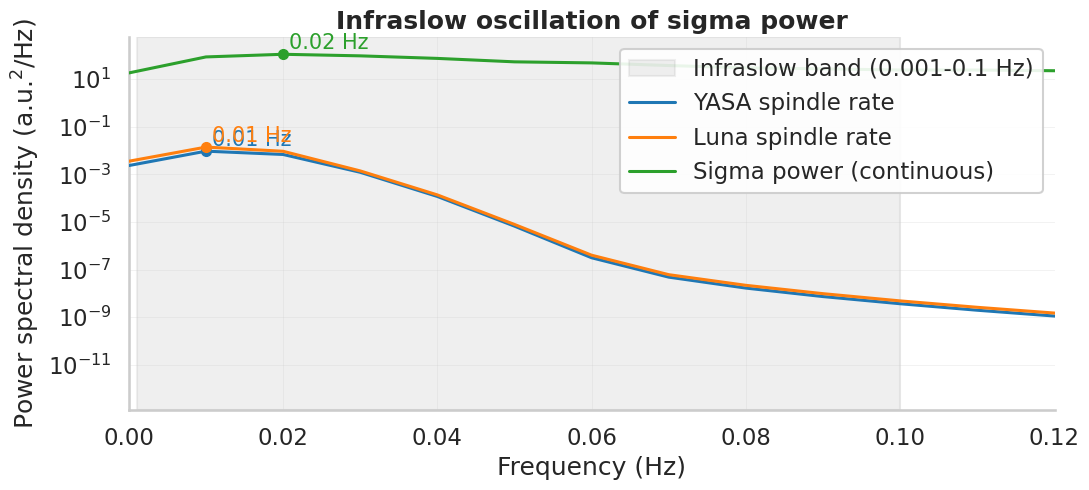

In [5]:
ax = plot_infraslow_spectra(
    {
        "YASA spindle rate": yasa_spec,
        "Luna spindle rate": luna_spec,
        "Sigma power (continuous)": sigma_spec,
    }
)
ax.figure.set_size_inches(11, 5)
plt.tight_layout()

## 5. Power-frequency of the spindle sigma band

The companion high-frequency view: the mean power spectrum of each detector's
detected spindle epochs (±1 s around every peak). The shaded sigma band and the
peak markers show where each detector's spindles concentrate -- YASA typically a
touch faster than Luna.

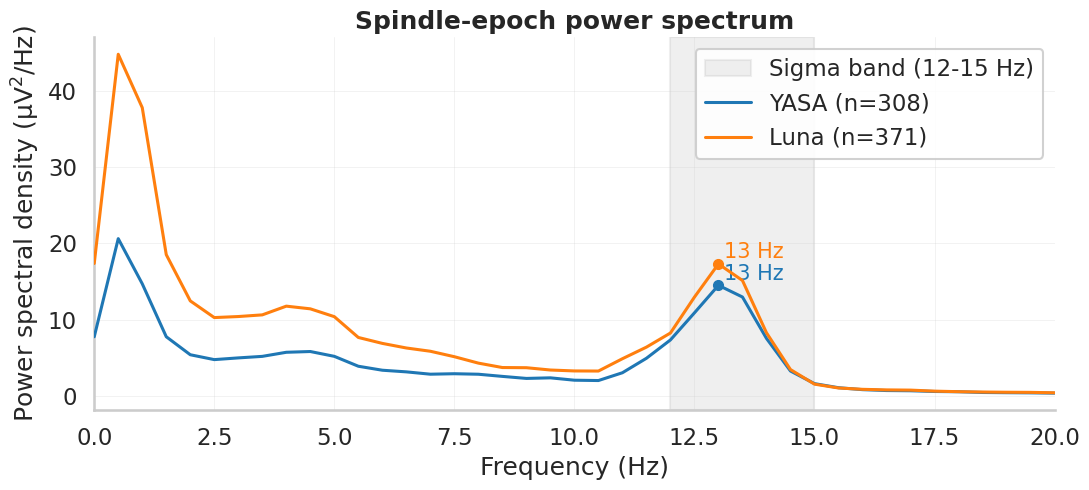

In [6]:
f_y, psd_y, n_y = average_spindle_spectrum(data, sf, yasa_peaks)
f_l, psd_l, n_l = average_spindle_spectrum(data, sf, luna_peaks)

ax = plot_spindle_sigma_spectra(
    {
        f"YASA (n={n_y})": (f_y, psd_y),
        f"Luna (n={n_l})": (f_l, psd_l),
    }
)
ax.figure.set_size_inches(11, 5)
plt.tight_layout()

## 6. Statistics

`compare_spindle_infraslow` tests each detector's infraslow-band power against an
**inter-spindle-interval shuffle** null (same count and ISI distribution, ~50 s
clustering destroyed): a small `p_value` means the infraslow rhythm is real, not
a by-product of the spindle rate. `associate_spindle_rate` then regresses the two
detectors' spindle-rate series on each other (statsmodels OLS) to test whether
they cluster spindles at the *same* times.

In [7]:
infra_stats = compare_spindle_infraslow(sp_yasa, sp_luna, duration_sec=duration_sec, n_perm=1000)
infra_stats.round(4)

,n_spindles,peak_freq,peak_power,full_peak_freq,band_power,rel_band_power,p_value,sig
detector,,,,,,,,
YASA,308,0.01,0.009492,0.01,0.00013,0.686771,0.841159,ns
Luna,371,0.01,0.014062,0.01,0.00018,0.670677,0.326673,ns


In [8]:
associate_spindle_rate(sp_yasa, sp_luna, duration_sec=duration_sec).to_frame().T

,n,pearson_r,r_squared,slope,p_value,sig
YASA~Luna,27510,0.758642,0.575537,0.881017,0.0,***


### Notes

* The infraslow peak is expected near **0.02 Hz (~50 s)** for both detectors; the
  continuous sigma-power reference is the ground truth the spindle-rate spectra
  are compared against.
* `rel_band_power` (fraction of the slow-series variance in the infraslow band)
  is the scale-free strength of the oscillation -- comparable across detectors
  despite their different spindle counts.
* The permutation test is single-subject: it asks whether *this* recording's
  spindles cluster at infraslow scale. A group-level YASA-vs-Luna contrast would
  pair the per-subject `rel_band_power` (or `peak_freq`) across subjects, mirroring
  the grand-average pattern in `infraslow.processing.detection`.
* Analysis lives in `infraslow.processing.infraslow`, plots in
  `infraslow.viz.infraslow`, and tests in `infraslow.stats.infraslow`.